<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA-ML-DL-Projects/blob/main/CREDIT_CARD_FRAUD_DETECTION_(PROJECT_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**
Credit card fraud has become a major challenge for banks and financial institutions due to the growing number of online and digital transactions. Fraudulent transactions can cause significant financial losses and reduce customer trust. Therefore, detecting fraud quickly and accurately is very important.

The main goal of this project is to build a machine learning classification model that can identify whether a credit card transaction is genuine or fraudulent. The dataset contains transaction details such as amount, transaction time, customer information, and merchant category, which can be used to detect suspicious activities.

In this project, Exploratory Data Analysis (EDA), data preprocessing, and machine learning techniques will be applied to analyze transaction patterns and predict fraud. The final model will help improve transaction security, reduce financial losses, and support financial institutions in making faster and more accurate fraud detection decisions.


# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Credit_Card_Fraud_Detection_100k.csv')
df.head(5)

,TransactionID,TransactionAmount,TransactionHour,MerchantCategory,CardType,CustomerAge,CustomerRegion,DeviceType,PreviousTransactions24H,AccountTenureMonths,InternationalTransaction,IsFraud
0,1,287.24,4,Electronics,Visa,74,East,Mobile,8,6,1,0
1,2,179.34,4,Food,Visa,46,South,Mobile,5,157,1,0
2,3,165.87,8,Travel,RuPay,59,Central,Desktop,2,113,0,0
3,4,165.88,19,Retail,RuPay,76,West,Desktop,11,138,0,0
4,5,557.97,20,Entertainment,Visa,63,West,Mobile,1,219,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   TransactionID             100000 non-null  int64  
 1   TransactionAmount         100000 non-null  float64
 2   TransactionHour           100000 non-null  int64  
 3   MerchantCategory          100000 non-null  object 
 4   CardType                  100000 non-null  object 
 5   CustomerAge               100000 non-null  int64  
 6   CustomerRegion            100000 non-null  object 
 7   DeviceType                100000 non-null  object 
 8   PreviousTransactions24H   100000 non-null  int64  
 9   AccountTenureMonths       100000 non-null  int64  
 10  InternationalTransaction  100000 non-null  int64  
 11  IsFraud                   100000 non-null  int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 9.2+ MB


In [ ]:
df.shape

(100000, 12)

In [ ]:
df.isnull().sum()

,0
TransactionID,0
TransactionAmount,0
TransactionHour,0
MerchantCategory,0
CardType,0
CustomerAge,0
CustomerRegion,0
DeviceType,0
PreviousTransactions24H,0
AccountTenureMonths,0


In [ ]:
df.dropna(subset=['InternationalTransaction'],inplace=True)
df.dropna(subset=['IsFraud'],inplace=True)

In [ ]:
df.isnull().sum()

,0
TransactionID,0
TransactionAmount,0
TransactionHour,0
MerchantCategory,0
CardType,0
CustomerAge,0
CustomerRegion,0
DeviceType,0
PreviousTransactions24H,0
AccountTenureMonths,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerAge', 'CustomerRegion',
       'DeviceType', 'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction', 'IsFraud'],
      dtype='object')

In [ ]:
target='IsFraud'

In [ ]:
df[target].value_counts()

,count
IsFraud,
0,98569
1,1431


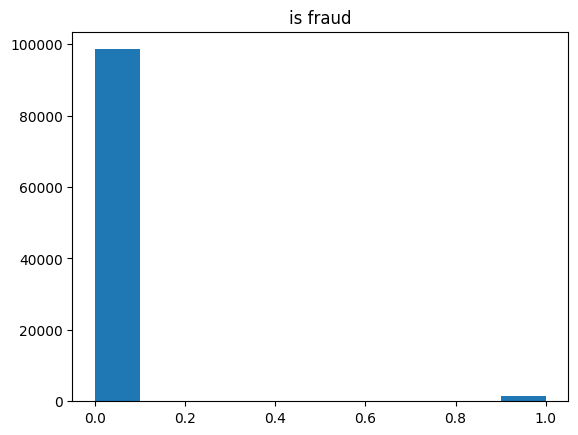

In [ ]:
plt.hist(df['IsFraud'])
plt.title('is fraud')
plt.show()

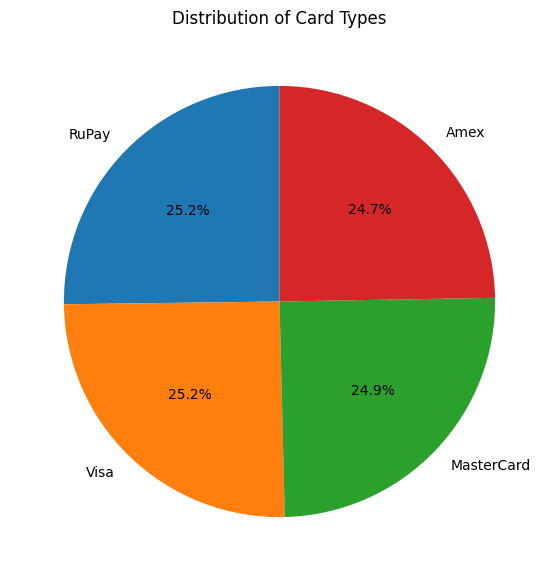

In [ ]:
card_counts = df['CardType'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(card_counts,
        labels=card_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of Card Types')
plt.show()

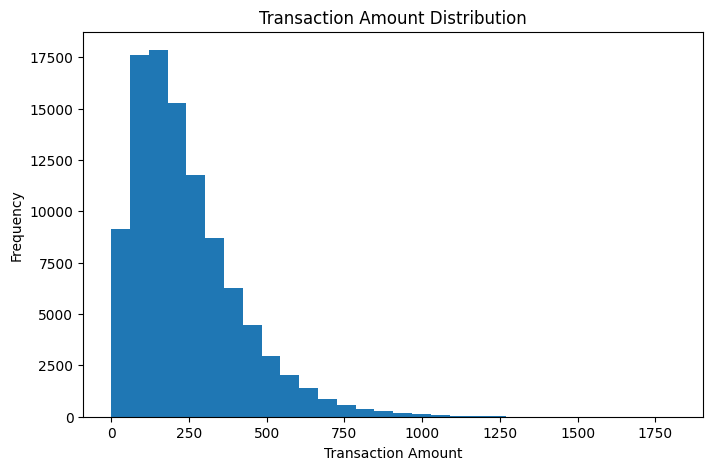

In [ ]:
counts = df['IsFraud'].value_counts()

plt.figure(figsize=(8,5))
plt.hist(df['TransactionAmount'], bins=30)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

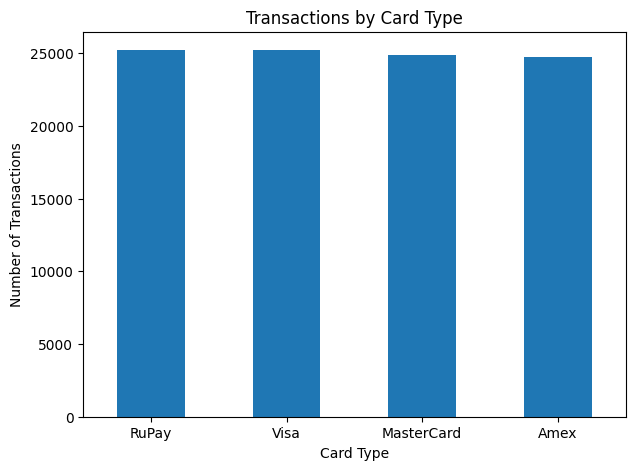

In [ ]:
card_counts = df['CardType'].value_counts()

plt.figure(figsize=(7,5))
card_counts.plot(kind='bar')

plt.title('Transactions by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['MerchantCategory', 'CardType', 'CustomerRegion', 'DeviceType'], dtype='object')

In [ ]:
print(df['MerchantCategory'].unique())

['Electronics' 'Food' 'Travel' 'Retail' 'Entertainment' 'Health']


In [ ]:
print(df['CardType'].unique())

['Visa' 'RuPay' 'Amex' 'MasterCard']


In [ ]:
print(df['CustomerRegion'].unique())

['East' 'South' 'Central' 'West' 'North']


In [ ]:
print(df['DeviceType'].unique())

['Mobile' 'Desktop' 'Tablet']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['MerchantCategory']=le.fit_transform(df['MerchantCategory'])
df['CardType']=le.fit_transform(df['CardType'])
df['CustomerRegion']=le.fit_transform(df['CustomerRegion'])
df['DeviceType']=le.fit_transform(df['DeviceType'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   TransactionID             100000 non-null  int64  
 1   TransactionAmount         100000 non-null  float64
 2   TransactionHour           100000 non-null  int64  
 3   MerchantCategory          100000 non-null  int64  
 4   CardType                  100000 non-null  int64  
 5   CustomerAge               100000 non-null  int64  
 6   CustomerRegion            100000 non-null  int64  
 7   DeviceType                100000 non-null  int64  
 8   PreviousTransactions24H   100000 non-null  int64  
 9   AccountTenureMonths       100000 non-null  int64  
 10  InternationalTransaction  100000 non-null  int64  
 11  IsFraud                   100000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 9.2 MB


In [ ]:
df.columns

Index(['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerAge', 'CustomerRegion',
       'DeviceType', 'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction', 'IsFraud'],
      dtype='object')

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

x=df[['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerAge', 'CustomerRegion',
       'DeviceType', 'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction']]
y=df['IsFraud']

smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['IsFraud'])],
    axis=1
)

print(df_resampled.head())

print(df_resampled['IsFraud'].value_counts())

   TransactionID  TransactionAmount  TransactionHour  MerchantCategory  \
0              1             287.24                4                 0   
1              2             179.34                4                 2   
2              3             165.87                8                 5   
3              4             165.88               19                 4   
4              5             557.97               20                 1   

   CardType  CustomerAge  CustomerRegion  DeviceType  PreviousTransactions24H  \
0         3           74               1           1                        8   
1         3           46               3           1                        5   
2         2           59               0           0                        2   
3         2           76               4           0                       11   
4         3           63               4           1                        1   

   AccountTenureMonths  InternationalTransaction  IsFraud  
0       

In [ ]:
df=df_resampled

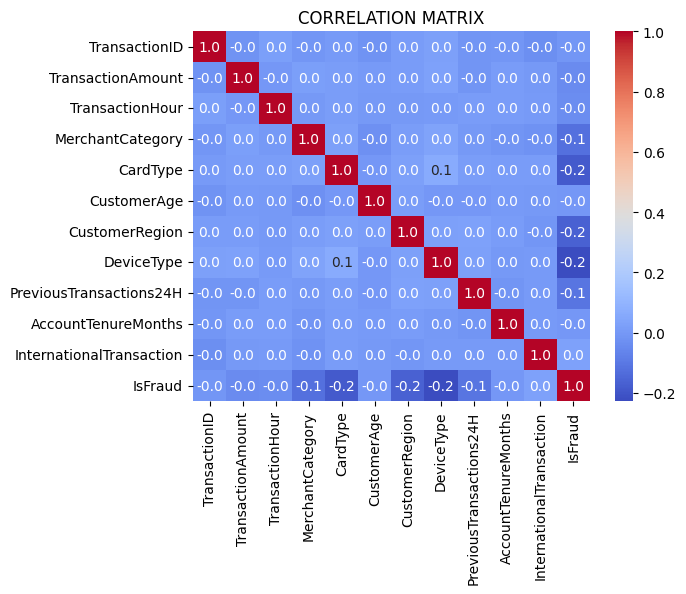

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('CORRELATION MATRIX')
plt.show()

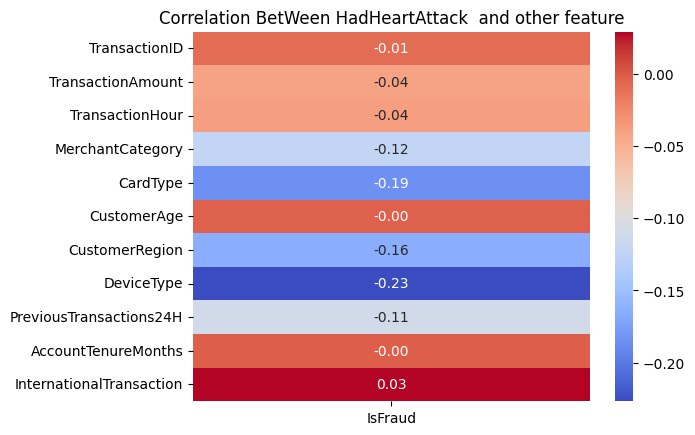

In [ ]:
status_corr=df.corr()['IsFraud']
status_corr=status_corr.drop('IsFraud')
sns.heatmap(status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation BetWeen HadHeartAttack  and other feature')
plt.show()

In [ ]:
df.columns

Index(['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerAge', 'CustomerRegion',
       'DeviceType', 'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction', 'IsFraud'],
      dtype='object')

In [ ]:
df.drop(['CustomerAge'],axis=1,inplace=True)

In [ ]:
df.shape

(197138, 11)

<Axes: >

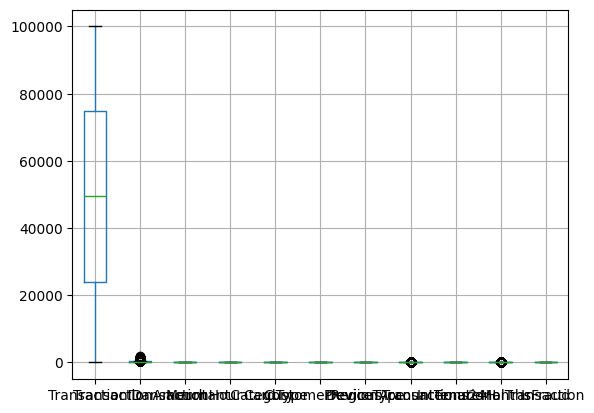

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='IsFraud')
df=df_cleaned

In [ ]:
df.columns

Index(['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerRegion', 'DeviceType',
       'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction', 'IsFraud'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerRegion', 'DeviceType',
       'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

# **MACHINE LEARNING**

In [ ]:
# LOGISTIC REGRESSION

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
x=df[['TransactionID', 'TransactionAmount', 'TransactionHour',
       'MerchantCategory', 'CardType', 'CustomerRegion', 'DeviceType',
       'PreviousTransactions24H', 'AccountTenureMonths',
       'InternationalTransaction']]
y=df['IsFraud']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.58


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# DECISION TREE

from sklearn.tree import DecisionTreeClassifier

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.91


In [ ]:
# SVC

from sklearn.preprocessing import MinMaxScaler,StandardScaler

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.66


In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.95


In [ ]:
# GRADIENTBOOSTER

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7574198748340603


In [ ]:
# ADA BOOST

from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.73


In [ ]:
# XGBOOST

from  xgboost import XGBClassifier

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.88


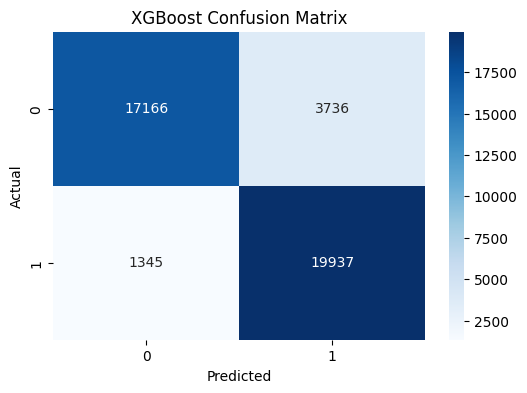

In [ ]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

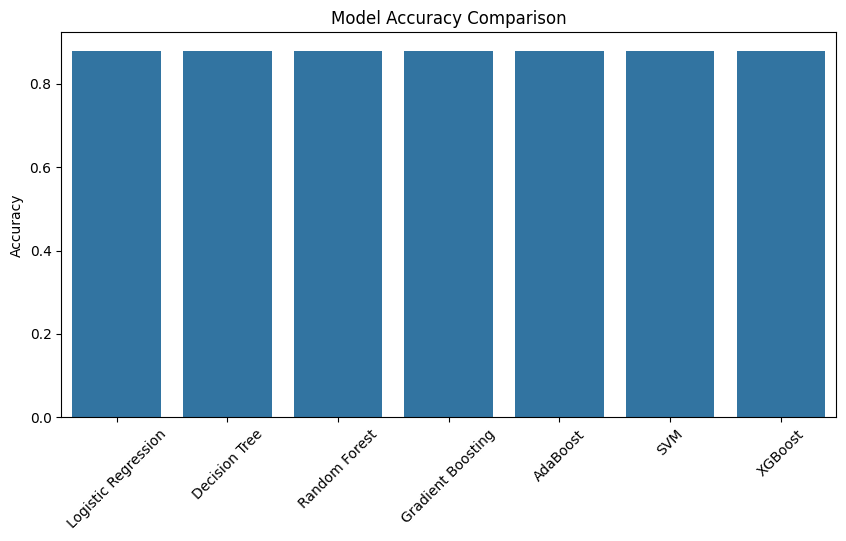

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred)]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# **K-FOLD CROSS VALIDATION**

In [ ]:
from sklearn.model_selection import KFold
x=df.drop('IsFraud',axis=1)
y=df['IsFraud']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_x_train=x_train
        best_y_train=y_train

        best_x_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1
Accuracy: 0.6555249355498266

Fold 2
Accuracy: 0.6584288973834711

Fold 3
Accuracy: 0.6588437490739918

Fold 4
Accuracy: 0.6599401428275106

Fold 5
Accuracy: 0.6569176519394316

Best Fold: 4 with Accuracy: 0.6599401428275106


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_x_train,best_y_train)
print("Logistic Regression:",model.score(best_x_test,best_y_test))

Logistic Regression: 0.6599401428275106


In [ ]:
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
print("Random Forest:",model.score(best_x_test,best_y_test))

Random Forest: 0.947461996621922


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("Decision Tree:",model.score(best_x_test,best_y_test))

Decision Tree: 0.9125255578273624


In [ ]:
model=SVC()
model.fit(best_x_train,best_y_train)
print("SVM:",model.score(best_x_test,best_y_test))

SVM: 0.4990962159599372


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("Gradient Boosting:",model.score(best_x_test,best_y_test))

Gradient Boosting: 0.7576673482087297


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("AdaBoost:",model.score(best_x_test,best_y_test))

AdaBoost: 0.7309094141701484


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_x_train,best_y_train)
print("XGBoost:",model.score(best_x_test,best_y_test))

XGBoost: 0.8790707322132337


# **DEEP LEARNING**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


model=Sequential()
model.add(Dense(64,input_shape=(x.shape[1],),activation='relu'))

model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(best_x_train,best_y_train,epochs=100)

y_pred=model.predict(best_x_test)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4219/4219 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.5039 - loss: 24.0142
Epoch 2/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5286 - loss: 2.0256
Epoch 3/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5100 - loss: 0.7340
Epoch 4/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5038 - loss: 0.6933
Epoch 5/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5041 - loss: 0.6978
Epoch 6/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5045 - loss: 0.6980
Epoch 7/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5058 - loss: 0.6930
Epoch 8/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5030 - loss: 0.6929
Epoch 9/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5025 - loss: 0.6927
Epoch 10/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5021 - loss: 0.6928
Epoch 11/100
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5023 - loss: 0.7077
Epoch 12/100
4219/421

# **CONCLUSION**

This project developed an AI-based Credit Card Fraud Detection System using Exploratory Data Analysis (EDA), machine learning, and deep learning techniques to identify fraudulent and legitimate credit card transactions. The dataset was analyzed and preprocessed to understand transaction patterns and improve the prediction performance of different algorithms.

Among all the models, Random Forest achieved the highest accuracy of 94.75%, followed by Decision Tree with 91.25% and XGBoost with 87.91%. Gradient Boosting, AdaBoost, and Logistic Regression also produced satisfactory results, while SVM and the deep learning model showed comparatively lower performance with accuracies of 49.91% and 50.45%, respectively. The results demonstrate that ensemble learning methods, particularly Random Forest and XGBoost, are highly effective for detecting credit card fraud and can support secure and reliable financial transactions.

# **FUTURE SCOPE**

In the future, this project can be enhanced by using larger real-world transaction datasets containing more complex fraud patterns to improve model robustness and generalization. Additional features such as transaction location, device information, and user behavioral patterns can be incorporated to increase prediction accuracy.

The system can further be integrated into real-time banking and payment systems to automatically detect suspicious transactions and generate instant alerts. Advanced deep learning techniques, anomaly detection methods, and explainable AI approaches can also be implemented to improve fraud detection performance and help financial institutions understand the factors contributing to fraudulent activities.